# 01 — Exploratory data analysis

A first look at the dataset of the IMA205 white blood cell challenge: 28,901 labelled training
images and 9,634 test images of single cells from peripheral blood smears, in 13 classes. The
two findings that shape everything that follows are the **extreme class imbalance** and the
**non-centred cells** on a stained background.

The data is not versioned; place the Kaggle files in `data/` (see the README).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

DATA = Path("..") / "data"
train_df = pd.read_csv(DATA / "train_metadata.csv")
test_df = pd.read_csv(DATA / "test_metadata.csv")
sample_sub = pd.read_csv(DATA / "sample_submission.csv")

print(f"Training images: {len(train_df):,}")
print(f"Test images:     {len(test_df):,}")
print(f"Classes:         {train_df['label'].nunique()}")
print(f"Submission file: {len(sample_sub):,} rows, columns {[c for c in sample_sub.columns if not c.startswith('Unnamed')]}")

Training images: 28,901
Test images:     9,634
Classes:         13
Submission file: 9,634 rows, columns ['ID', 'label']


## Class distribution

       count  share (%)
label                  
SNE    13015      45.03
LY      8101      28.03
MO      2746       9.50
BL      2012       6.96
EO       861       2.98
MY       441       1.53
BA       415       1.44
BNE      391       1.35
VLY      366       1.27
MMY      360       1.25
PMY      114       0.39
PC        68       0.24
PLY       11       0.04

Imbalance ratio (largest / smallest class): 1183:1
Median class size: 415
Classes with fewer than 100 images: 2


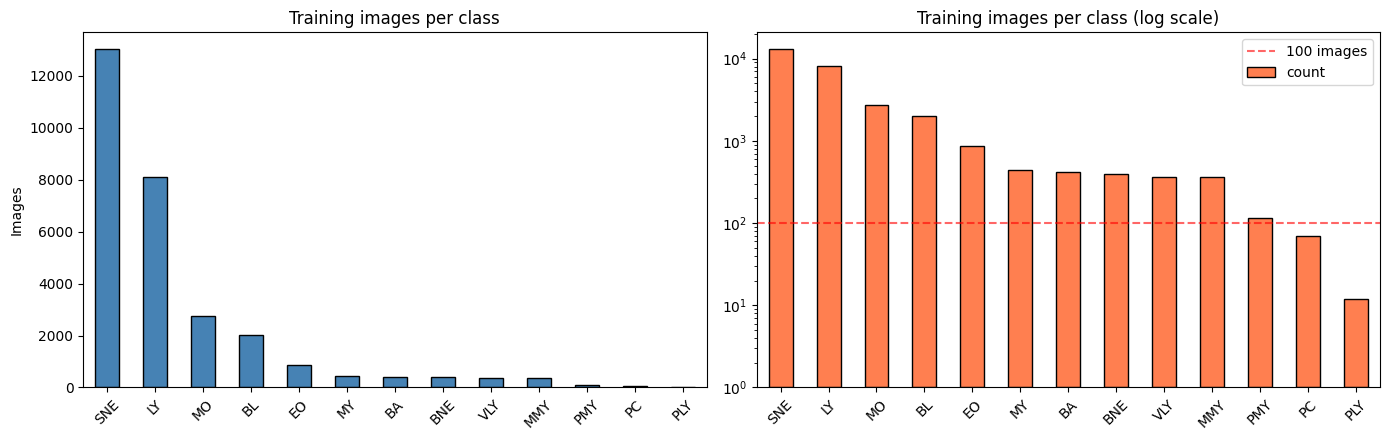

In [2]:
class_counts = train_df['label'].value_counts()
summary = pd.DataFrame({'count': class_counts,
                        'share (%)': (100 * class_counts / len(train_df)).round(2)})
print(summary.to_string())
print(f"\nImbalance ratio (largest / smallest class): {class_counts.iloc[0] / class_counts.iloc[-1]:.0f}:1")
print(f"Median class size: {int(class_counts.median())}")
print(f"Classes with fewer than 100 images: {(class_counts < 100).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
class_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title("Training images per class")
axes[0].set_ylabel("Images")
class_counts.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black', log=True)
axes[1].axhline(100, color='red', linestyle='--', alpha=0.6, label='100 images')
axes[1].set_title("Training images per class (log scale)")
axes[1].legend()
for ax in axes:
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Two classes (SNE and LY) make up about three quarters of the training set, while PLY has only 11
images. Accuracy would therefore be misleading: the challenge metric is the **macro-F1**, which
weighs every class equally, and the rare classes drive most of the modelling choices
(oversampling, SMOTE, class-balanced sampling).

## Image size and appearance

In [3]:
sample_ids = train_df.sample(200, random_state=42)['ID']
sizes = pd.Series([Image.open(DATA / "train" / i).size for i in sample_ids])
print("Image sizes (width x height) in a random sample of 200 training images:")
print(sizes.value_counts().to_string())

Image sizes (width x height) in a random sample of 200 training images:
(368, 368)    111
(368, 370)     89


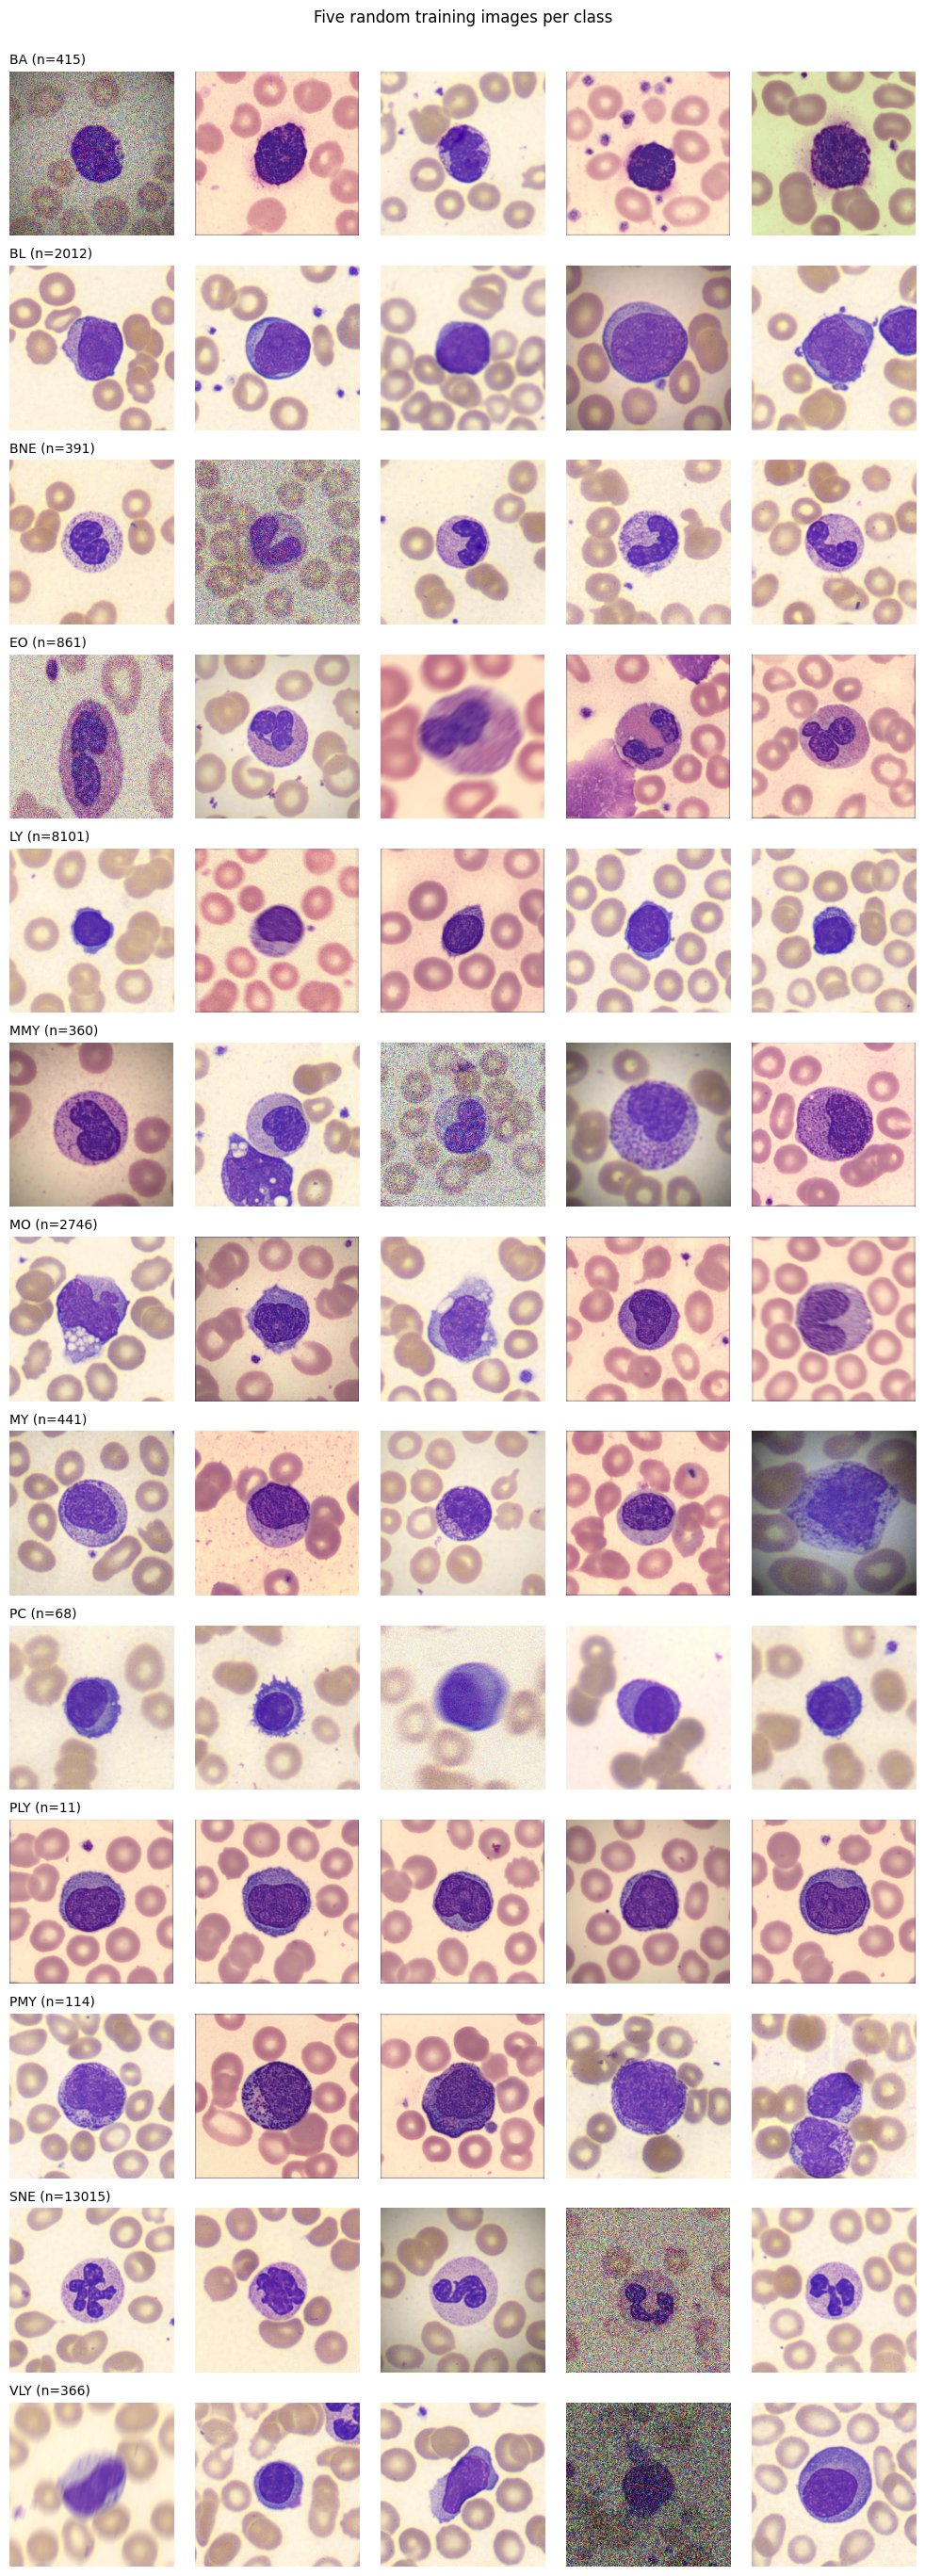

In [4]:
classes = sorted(train_df['label'].unique())
fig, axes = plt.subplots(len(classes), 5, figsize=(10, 2.1 * len(classes)))
for i, cls in enumerate(classes):
    cls_df = train_df[train_df['label'] == cls]
    samples = cls_df.sample(min(5, len(cls_df)), random_state=42)
    for j in range(5):
        ax = axes[i, j]
        ax.axis('off')
        if j < len(samples):
            ax.imshow(Image.open(DATA / "train" / samples.iloc[j]['ID']).convert('RGB'))
    axes[i, 0].set_title(f"{cls} (n={len(cls_df)})", loc='left', fontsize=10)
plt.suptitle("Five random training images per class", y=1.0)
plt.tight_layout()
plt.show()

## Takeaways

- Images are almost all 368×368 or 368×370 px; they are resized to a fixed size by every model.
- The cell of interest is not always centred and neighbouring red cells or other white cells
  can appear in the frame. This motivates the segmentation step of the classical pipeline
  (`02_classical_ml.ipynb`) and the HSV-based cell cropping of the deep-learning pipeline
  (`04_final_model.ipynb`).
- Several classes are visually close (SNE vs BNE, LY vs VLY, MMY vs MY), which is where a large
  share of the errors of the final model are concentrated.